## Importing Necessary Pacakages

In [1]:
!pip install datasets
# !pip install googletrans==3.1.0a0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.7/472.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.5 MB/s eta 0:00:00


In [2]:
import requests
from PIL import Image
import torch
from transformers import BlipProcessor, BlipForQuestionAnswering,BlipImageProcessor, AutoProcessor
from transformers import BlipConfig
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import warnings

warnings.filterwarnings("ignore")

## Load Dataset

In [ ]:
# data_set # View the datasetDict

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [70]:
%cd /content/drive/MyDrive/model_ilab/data

/content/drive/MyDrive/model_ilab/data


In [71]:
df = pd.read_csv('slake.csv', index_col=0)

In [72]:
df.shape

(11934, 12)

In [73]:
df.location.unique()

array(['Abdomen', 'Lung', 'Chest_heart', 'Chest_lung', 'Brain_Tissue',
       'Brain_Face', 'Brain', 'Neck', 'Chest_mediastinal',
       'Pelvic Cavity'], dtype=object)

In [74]:
# data which modality is mri and location is Brain or Brain Tissue
df = df[(df['modality'] == 'MRI') & ((df['location'] == 'Brain') | (df['location'] == 'Brain_Tissue'))]
df.shape

(2080, 12)

In [75]:
%cd /content/drive/MyDrive/model_ilab/data/imgs

/content/drive/MyDrive/model_ilab/data/imgs


Question: How is this picture imaged?
Answer: NMR


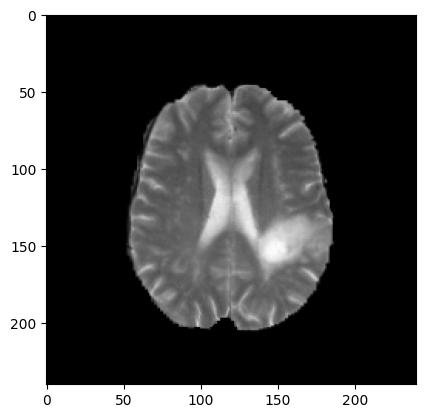

In [76]:
sample = df.sample(1).iloc[0]
img_path = sample['img_name']
image = Image.open(img_path)
PIL_image = Image.fromarray(np.array(image)).convert('RGB')
plt.imshow(image.convert('RGB'))
print("Question: {}".format(sample['question']))
print("Answer: {}".format(sample['answer']))

## Explore Data

In [77]:
df.shape #shape of data

(2080, 12)

In [78]:
df.head() #first 5 rows of data

,img_name,location,answer,modality,base_type,answer_type,question,qid,content_type,triple,img_id,q_lang
2996,xmlab41/source.jpg,Brain,MRI,MRI,vqa,OPEN,What modality is used to take this image?,2996,Modality,"['vhead', '_', '_']",41,en
2997,xmlab41/source.jpg,Brain,Brain,MRI,vqa,OPEN,Which part of the body does this image belong to?,2997,Position,"['vhead', '_', '_']",41,en
2998,xmlab41/source.jpg,Brain,T2,MRI,vqa,OPEN,What is the mr weighting in this image?,2998,Modality,"['vhead', '_', '_']",41,en
2999,xmlab41/source.jpg,Brain,Brain,MRI,vqa,OPEN,What is the main organ in the image?,2999,Organ,"['vhead', '_', '_']",41,en
3000,xmlab41/source.jpg,Brain,Brain,MRI,vqa,OPEN,What is the largest organ in the picture?,3000,Size,"['vhead', '_', '_']",41,en


In [80]:
df.isna().sum()

,0
img_name,0
location,0
answer,26
modality,0
base_type,0
answer_type,0
question,0
qid,0
content_type,0
triple,0


In [81]:
df.dropna(inplace=True)

In [82]:
%cd /content/drive/MyDrive/model_ilab/

/content/drive/MyDrive/model_ilab


In [83]:
config = BlipConfig.from_pretrained("./blip_finetuned_model_vqa_slake_27_Oct")

In [84]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [85]:
class VQADataset(torch.utils.data.Dataset):
    def __init__(self, data, segment, text_processor, image_processor):
        self.data = data
        self.text_processor = text_processor
        self.image_processor = image_processor
        self.max_length = 32
        self.image_height = 128
        self.image_width = 128

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # get image + text
        answers = self.data.iloc[idx]['answer']
        question = self.data.iloc[idx]['question']
        image_path = self.data.iloc[idx]['img_name']
        image = Image.open(image_path)
        image = image.convert('RGB')
        text = question

        image_encoding = self.image_processor(image,
                                  do_resize=True,
                                  size=(self.image_height,self.image_width),
                                  return_tensors="pt")

        encoding = self.text_processor(
                                  None,
                                  text,
                                  padding="max_length",
                                  truncation=True,
                                  max_length = self.max_length,
                                  return_tensors="pt"
                                  )
        # # remove batch dimension
        for k,v in encoding.items():
            encoding[k] = v.squeeze()
        encoding["pixel_values"] = image_encoding["pixel_values"][0]
        # # add labels
        labels = self.text_processor.tokenizer.encode(
            answers,
            max_length= self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors='pt'
        )[0]
        encoding["labels"] = labels

        return encoding

In [86]:
text_processor = BlipProcessor.from_pretrained("./blip_finetuned_model_vqa_slake_27_Oct")
image_processor = BlipImageProcessor.from_pretrained("./blip_finetuned_model_vqa_slake_27_Oct")

In [87]:
train_vqa_dataset = VQADataset(data=train_df,
                     segment='train',
                     text_processor = text_processor,
                     image_processor = image_processor
                         )

val_vqa_dataset = VQADataset(data=val_df,
                     segment='validation',
                     text_processor = text_processor,
                     image_processor = image_processor
                         )

In [88]:
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    pixel_values = [item['pixel_values'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    labels = [item['labels'] for item in batch]
    # create new batch
    batch = {}
    batch['input_ids'] = torch.stack(input_ids)
    batch['attention_mask'] = torch.stack(attention_mask)
    batch['pixel_values'] = torch.stack(pixel_values)
    batch['labels'] = torch.stack(labels)

    return batch

In [89]:
train_dataloader = DataLoader(train_vqa_dataset,
                              collate_fn=collate_fn,
                              batch_size=64,
                              shuffle=False)
val_dataloader = DataLoader(val_vqa_dataset,
                            collate_fn=collate_fn,
                            batch_size=64,
                            shuffle=False)

In [90]:
%cd /content/drive/MyDrive/model_ilab/data/imgs

/content/drive/MyDrive/model_ilab/data/imgs


In [91]:
batch = next(iter(train_dataloader))
for key,value in batch.items():
    print(key, value.shape)

input_ids torch.Size([64, 32])
attention_mask torch.Size([64, 32])
pixel_values torch.Size([64, 3, 128, 128])
labels torch.Size([64, 32])


In [93]:
%cd /content/drive/MyDrive/model_ilab/

/content/drive/MyDrive/model_ilab


In [94]:
model = BlipForQuestionAnswering.from_pretrained("./blip_finetuned_model_vqa_slake_27_Oct" )
model.to(device)

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

In [95]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
image_mean = image_processor.image_mean
image_std = image_processor.image_std

Question:  [CLS] is this a coronal plane? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
Answer:  [CLS] no [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


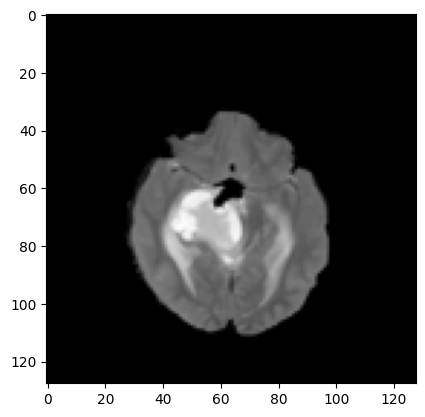

In [96]:
batch_idx = 1

unnormalized_image = (batch["pixel_values"][batch_idx].cpu().numpy() * np.array(image_std)[:, None, None]) + np.array(image_mean)[:, None, None]
unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
unnormalized_image = (unnormalized_image * 255).astype(np.uint8)

print("Question: ",text_processor.decode(batch["input_ids"][batch_idx]))
print("Answer: ",text_processor.decode(batch["labels"][batch_idx]))
plt.imshow(Image.fromarray(unnormalized_image))

In [97]:
val_loss = []
train_loss = []
min_val_loss = float('Inf')
num_epoch = 20

In [98]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# Assuming the rest of your model and data loader setup remains the same

# Define the early stopping criteria and scheduler
patience = 5  # Stop training after 'patience' epochs without improvement
early_stopping_counter = 0
min_val_loss = float('inf')  # Track the minimum validation loss

# Define learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

In [101]:
%cd /content/drive/MyDrive/model_ilab/data/imgs

/content/drive/MyDrive/model_ilab/data/imgs


In [102]:
for epoch in range(num_epoch):
    model.train()
    total_loss = []

    for batch in tqdm(train_dataloader, desc=f"Epoch [{epoch+1}/{num_epoch}]"):
        # Move batch to device
        batch = {key: value.to(device) for key, value in batch.items()}

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss
        total_loss.append(loss.item())

        # Backward pass and optimization step
        loss.backward()
        optimizer.step()

    # Calculate and store average training loss for this epoch
    avg_train_loss = sum(total_loss) / len(train_dataloader)
    train_loss.append(avg_train_loss)

    # Evaluate on validation set
    model.eval()
    total_val_loss = []
    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_val_loss.append(loss.item())

    # Calculate and store average validation loss for this epoch
    avg_val_loss = sum(total_val_loss) / len(val_dataloader)
    val_loss.append(avg_val_loss)

    # Adjust learning rate based on validation loss
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epoch} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # Save the best model if validation loss improves
    if avg_val_loss < min_val_loss:
        min_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Validation loss decreased. Saving model...")
        early_stopping_counter = 0  # Reset counter for improvement
    else:
        early_stopping_counter += 1  # Increment counter if no improvement

    # Check for early stopping
    if early_stopping_counter >= patience:
        print(f"Early stopping after {epoch+1} epochs due to no improvement in validation loss.")
        break


Epoch [1/20]: 100%|██████████| 26/26 [00:31<00:00,  1.22s/it]


Epoch 1/20 - Train Loss: 0.0416 - Val Loss: 0.0210
Validation loss decreased. Saving model...


Epoch [2/20]: 100%|██████████| 26/26 [00:19<00:00,  1.36it/s]


Epoch 2/20 - Train Loss: 0.0267 - Val Loss: 0.0204
Validation loss decreased. Saving model...


Epoch [3/20]: 100%|██████████| 26/26 [00:19<00:00,  1.35it/s]


...

Epoch 14/20 - Train Loss: 0.0021 - Val Loss: 0.0119


Epoch [15/20]: 100%|██████████| 26/26 [00:15<00:00,  1.66it/s]


Epoch 15/20 - Train Loss: 0.0020 - Val Loss: 0.0120


Epoch [16/20]: 100%|██████████| 26/26 [00:15<00:00,  1.68it/s]


Epoch 16/20 - Train Loss: 0.0020 - Val Loss: 0.0120
Early stopping after 16 epochs due to no improvement in validation loss.


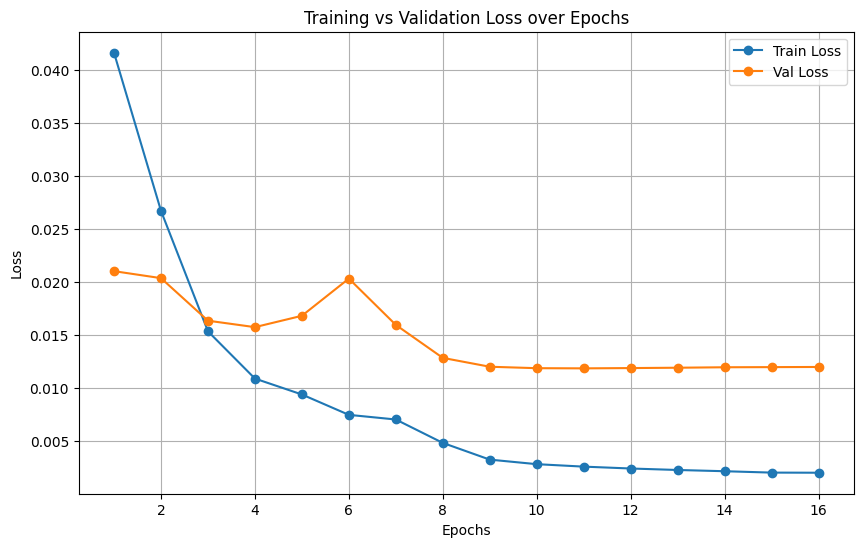

In [103]:
import matplotlib.pyplot as plt

# Create a list for the number of epochs (assuming num_epoch is the total number of epochs)
epochs = range(1, len(train_loss) + 1)

# Plotting the data
plt.figure(figsize=(10,6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Val Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss over Epochs')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

In [104]:
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

Question:  which part of the body does the area included in the image belong to?
Predicted Answer:  medical treatment, supportive care, surgical treatment
Actual Answer:  brain


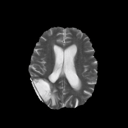

Question:  where is the brain edema located?
Predicted Answer:  lower right lobe
Actual Answer:  lower right lobe


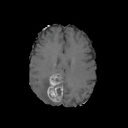

Question:  what kind of symptoms will the disease on the right lobe of brain in the picture bring to the patient?
Predicted Answer:  visual impairment, vomiting, tinnitus, increased intracranial pressure
Actual Answer:  visual impairment, vomiting, tinnitus, increased intracranial pressure


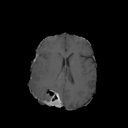

Question:  does the picture contain brian?
Predicted Answer:  yes
Actual Answer:  yes


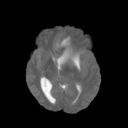

Question:  what disease is / are shown on the upper left of brain?
Predicted Answer:  brain
Actual Answer:  brain edema


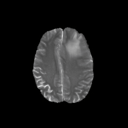

Question:  is the abnormality hyperdense or hypodense?
Predicted Answer:  hyperdense
Actual Answer:  hyperdense


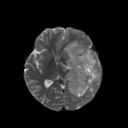

Question:  are the anomalies in the graph high - density or low - density?
Predicted Answer:  high density
Actual Answer:  high density


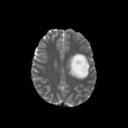

Question:  is the tumor in the picture enhancing?
Predicted Answer:  yes
Actual Answer:  no


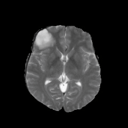

Question:  what is the mr weighting in this image?
Predicted Answer:  yes
Actual Answer:  t2


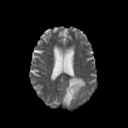

Question:  where does the picture show?
Predicted Answer:  can
Actual Answer:  head


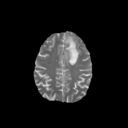

In [105]:
# add batch dimension + move to GPU|
for x in range(10):
    random_10_int = np.random.randint(0, len(val_vqa_dataset))
    random_index = x + random_10_int
    sample = val_vqa_dataset[random_index]
    print("Question: ",text_processor.decode(sample['input_ids'], skip_special_tokens=True))
    sample = {k: v.unsqueeze(0).to(device) for k,v in sample.items()}

    # forward pass
    outputs = model.generate(pixel_values=sample['pixel_values'],
                            input_ids=sample['input_ids'])
    print("Predicted Answer: ",text_processor.decode(outputs[0],skip_special_tokens=True))
    print("Actual Answer: ",text_processor.decode(sample['labels'][0], skip_special_tokens=True))
    unnormalized_image = (sample["pixel_values"][0].cpu().numpy() * np.array(image_std)[:, None, None]) + np.array(image_mean)[:, None, None]
    unnormalized_image = (unnormalized_image * 255).astype(np.uint8)
    unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
    display(Image.fromarray(unnormalized_image))

In [106]:
# Initialize total loss and BLEU score metric
total_loss = 0
predictions = []
references = []

In [107]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Function to calculate BLEU-1 to BLEU-4 on the entire validation set
def calculate_bleu_scores(val_vqa_dataset, model, text_processor, device):
    total_bleu1 = 0.0
    total_bleu2 = 0.0
    total_bleu3 = 0.0
    total_bleu4 = 0.0
    num_samples = len(val_vqa_dataset)
    smoothing_fn = SmoothingFunction().method1  # To avoid division by zero in small datasets

    for idx in range(num_samples):
        # Load sample and move to GPU
        sample = val_vqa_dataset[idx]
        sample = {k: v.unsqueeze(0).to(device) for k, v in sample.items()}

        # Generate model's predicted output
        outputs = model.generate(pixel_values=sample['pixel_values'],
                                 input_ids=sample['input_ids'])

        # Decode predicted and actual answers
        predicted_answer = text_processor.decode(outputs[0], skip_special_tokens=True)
        actual_answer = text_processor.decode(sample['labels'][0], skip_special_tokens=True)

        # Tokenize both the reference and predicted answers
        reference = actual_answer.split()
        candidate = predicted_answer.split()

        # Calculate BLEU scores for 1-gram to 4-gram
        bleu1 = sentence_bleu([reference], candidate, weights=(1, 0, 0, 0), smoothing_function=smoothing_fn)
        bleu2 = sentence_bleu([reference], candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing_fn)
        bleu3 = sentence_bleu([reference], candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing_fn)
        bleu4 = sentence_bleu([reference], candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_fn)

        # Accumulate the BLEU scores
        total_bleu1 += bleu1
        total_bleu2 += bleu2
        total_bleu3 += bleu3
        total_bleu4 += bleu4

    # Calculate the average BLEU scores for the validation set
    avg_bleu1 = total_bleu1 / num_samples
    avg_bleu2 = total_bleu2 / num_samples
    avg_bleu3 = total_bleu3 / num_samples
    avg_bleu4 = total_bleu4 / num_samples

    # Print the final average BLEU-1 to BLEU-4 scores
    print(f"Average BLEU-1 Score: {avg_bleu1:.4f}")
    print(f"Average BLEU-2 Score: {avg_bleu2:.4f}")
    print(f"Average BLEU-3 Score: {avg_bleu3:.4f}")
    print(f"Average BLEU-4 Score: {avg_bleu4:.4f}")

In [108]:
# Example usage
calculate_bleu_scores(val_vqa_dataset, model, text_processor, device)

Average BLEU-1 Score: 0.3926
Average BLEU-2 Score: 0.1984
Average BLEU-3 Score: 0.1428
Average BLEU-4 Score: 0.1172


In [109]:
%cd /content/drive/MyDrive/model_ilab

/content/drive/MyDrive/model_ilab


In [110]:
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch

# Path to the saved model and processor
model_save_path = "./blip_finetuned_model_27_Oct_v2"

# save model
model.save_pretrained(model_save_path)

# save processor
text_processor.save_pretrained(model_save_path)

[]

In [111]:
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch

# Load the fine-tuned model and processor
processor = BlipProcessor.from_pretrained(model_save_path)
loaded_model = BlipForQuestionAnswering.from_pretrained(model_save_path)

# Move the model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

Saving 48a84621866d6fa822105f72e6d3295ac6cf4f2ca73063b11fd4de76a617a8bf_big_gallery.jpeg to 48a84621866d6fa822105f72e6d3295ac6cf4f2ca73063b11fd4de76a617a8bf_big_gallery (6).jpeg


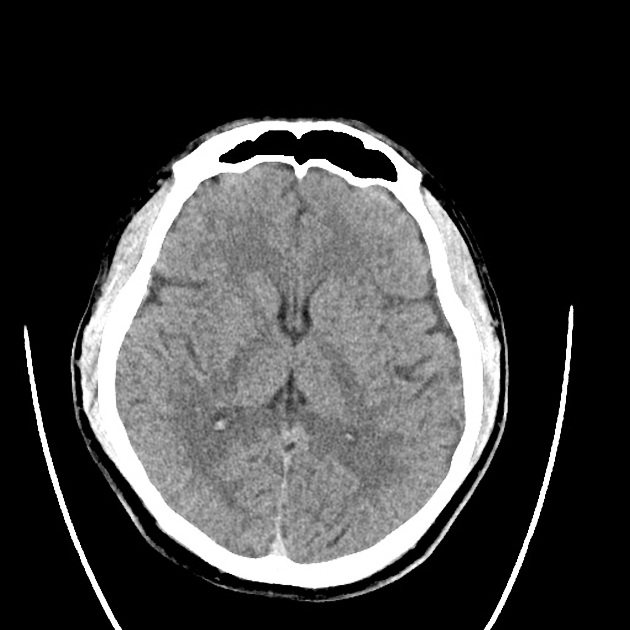

Enter your question: what is this?
Predicted Answer: brain edema, brain enhancing tumor, brain non - enhancing tumor
Enter your question: what does the picture show?
Predicted Answer: head
Enter your question: is this head?
Predicted Answer: yes
Enter your question: is this liver?
Predicted Answer: no
Enter your question: is this lungs?
Predicted Answer: no
Enter your question: is this abdomen?
Predicted Answer: no
Enter your question: is this brain?
Predicted Answer: yes
Enter your question: exit


In [112]:
from PIL import Image

# Replace with your image path in Google Drive
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Open the image
image = Image.open(image_path)
display(image)

# Question prompt
while True:
  question = str(input("Enter your question: "))

  if question == "exit":
    break
  # Preprocess the image and question using the processor
  inputs = processor(image, question, return_tensors="pt").to("cuda")

  # Forward pass to generate the output (move to GPU and generate)
  with torch.no_grad():
      outputs = loaded_model.generate(pixel_values=inputs['pixel_values'],
                              input_ids=inputs['input_ids'])

  # Decode the predicted answer
  predicted_answer = processor.decode(outputs[0], skip_special_tokens=True)

  print(f"Predicted Answer: {predicted_answer}")